### Pacotes importados

In [1]:
using LinearAlgebra
using Printf
using Plots
using ForwardDiff

## Chapter 13: Quasi-Newton methods

### Algorithm 13.1: Quasi-Newton BFGS method

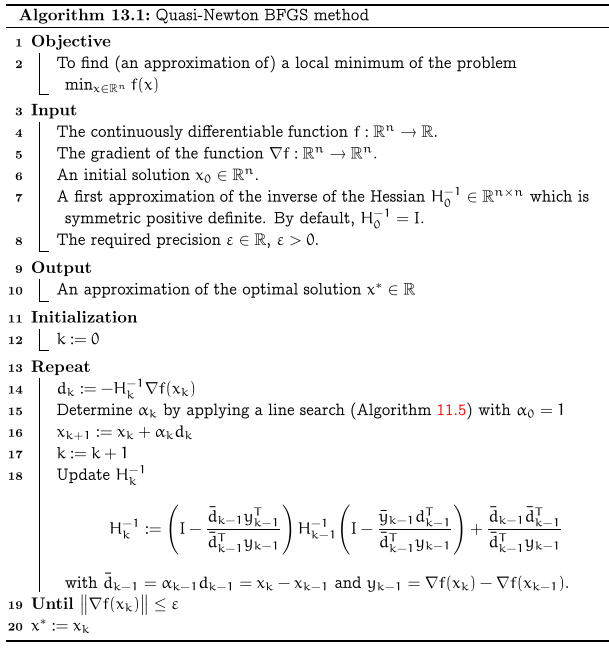

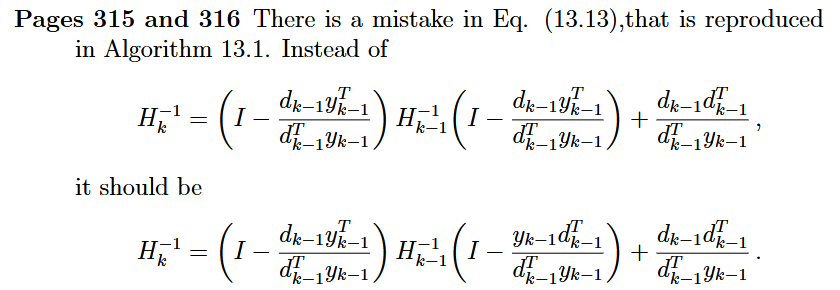

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$

  k                 x1                 x2               f(x)           ||grad||              alpha
  0  +1.0000000000E+00  +1.0000000000E+00  +1.0403023059E+00  +1.7551651238E+00  +1.0000000000E+00
  1  -5.4030230587E-01  +1.8414709848E+00  +2.9043018140E-01  +9.6094181803E-01  +1.0000000000E+00
  2  -1.8900925969E-02  +1.5052776232E+00  -1.0588558672E-03  +5.0245034816E-02  +1.0000000000E+00

BFGS update stopped: sᵀy <= 0.

Resultado final:
x = [-0.054389120857192955, 1.4806158114630743]
f(x) = -0.003419105295138743
gradiente = [0.035669211613539156, 0.054168110247370775]
||grad|| = 0.06485735752328144


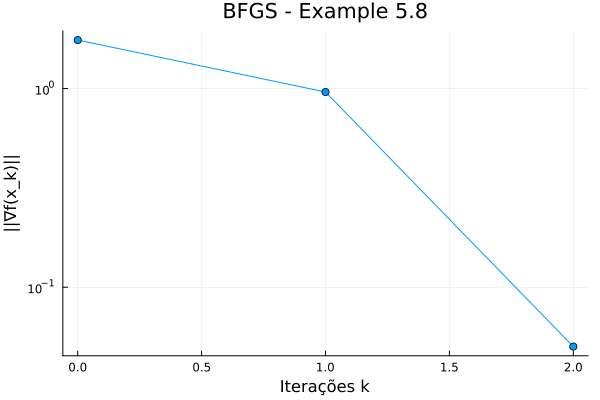

In [2]:

# Example 5.8
f(x) = 0.5*x[1]^2 + x[1]*cos(x[2])

grad_f(x) = ForwardDiff.gradient(f, x)

function line_search_armijo(f, grad_f, x, d; alpha0=1.0, beta=0.5, c=1e-4)
    alpha = alpha0
    fx = f(x)
    g = grad_f(x)

    while f(x + alpha*d) > fx + c*alpha*dot(g, d)
        alpha *= beta
    end

    return alpha
end

x = [1.0, 1.0]
epsilon = 1e-8
maxiter = 100

n = length(x)
Hinv = Matrix{Float64}(I, n, n)

ks = Int[]
values = Float64[]
gradnorms = Float64[]

@printf("%3s %18s %18s %18s %18s %18s\n",
        "k", "x1", "x2", "f(x)", "||grad||", "alpha")

for k in 0:maxiter
    g = grad_f(x)
    normg = norm(g)

    push!(ks, k)
    push!(values, abs(f(x)) + 1e-16)
    push!(gradnorms, max(normg, 1e-16))

    if normg <= epsilon
        break
    end

    d = -Hinv * g
    alpha = line_search_armijo(f, grad_f, x, d)

    @printf("%3d %+18.10E %+18.10E %+18.10E %+18.10E %+18.10E\n",
            k, x[1], x[2], f(x), normg, alpha)

    x_old = copy(x)
    g_old = copy(g)

    x = x + alpha*d
    g_new = grad_f(x)

    s = x - x_old
    y = g_new - g_old
    sy = dot(s, y)

    if sy <= 1e-14
        println("\nBFGS update stopped: sᵀy <= 0.")
        break
    end

    rho = 1.0 / sy
    I_n = Matrix{Float64}(I, n, n)

    Hinv = (I_n - rho*s*y') * Hinv * (I_n - rho*y*s') + rho*(s*s')
end

println("\nResultado final:")
println("x = ", x)
println("f(x) = ", f(x))
println("gradiente = ", grad_f(x))
println("||grad|| = ", norm(grad_f(x)))

plot(
    ks,
    gradnorms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||∇f(x_k)||",
    title = "BFGS - Example 5.8",
    legend = false,
    yscale = :log10
)

#### the Rosenbrock problem

  k                 x1                 x2               f(x)           ||grad||              alpha
  0  -1.2000000000E+00  +1.0000000000E+00  +2.4200000000E+01  +2.3286768775E+02  +9.7656250000E-04
  1  -9.8945312500E-01  +1.0859375000E+00  +5.1011126637E+00  +4.3898520923E+01  +1.2500000000E-01
  2  -7.7234580598E-01  +5.7059239834E-01  +3.2084235664E+00  +1.2664248340E+01  +1.0000000000E+00
  3  -7.4128546994E-01  +5.1842587073E-01  +3.1286610193E+00  +1.4137414652E+01  +1.0000000000E+00
  4  -4.6315775757E-01  +1.4171129541E-01  +2.6708701420E+00  +2.1941763266E+01  +1.0000000000E+00
  5  -4.9759058772E-01  +2.6729175379E-01  +2.2815682921E+00  +4.0462015108E+00  +1.0000000000E+00
  6  -3.8197111319E-01  +1.3390898662E-01  +1.9242272299E+00  +5.1845383517E+00  +2.5000000000E-01
  7  -3.0475089852E-01  +5.8293626948E-02  +1.8219489730E+00  +9.7163204425E+00  +1.0000000000E+00
  8  -2.6165859904E-01  +3.6136852448E-02  +1.6962947712E+00  +8.7576590587E+00  +1.0000000000E+00
  9  -1.23

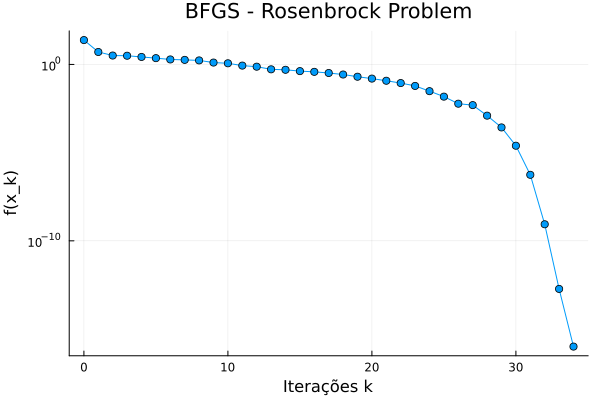

In [3]:

# Rosenbrock problem
f(x) = 100*(x[2] - x[1]^2)^2 + (1 - x[1])^2

grad_f(x) = ForwardDiff.gradient(f, x)

function line_search_armijo(f, grad_f, x, d; alpha0=1.0, beta=0.5, c=1e-4)
    alpha = alpha0
    fx = f(x)
    g = grad_f(x)

    while f(x + alpha*d) > fx + c*alpha*dot(g, d)
        alpha *= beta
    end

    return alpha
end

x = [-1.2, 1.0]
epsilon = 1e-8
maxiter = 1000

n = length(x)
Hinv = Matrix{Float64}(I, n, n)

ks = Int[]
values = Float64[]
gradnorms = Float64[]

@printf("%3s %18s %18s %18s %18s %18s\n",
        "k", "x1", "x2", "f(x)", "||grad||", "alpha")

for k in 0:maxiter
    g = grad_f(x)
    normg = norm(g)

    push!(ks, k)
    push!(values, max(f(x), 1e-16))
    push!(gradnorms, max(normg, 1e-16))

    if normg <= epsilon
        break
    end

    d = -Hinv * g
    alpha = line_search_armijo(f, grad_f, x, d)

    @printf("%3d %+18.10E %+18.10E %+18.10E %+18.10E %+18.10E\n",
            k, x[1], x[2], f(x), normg, alpha)

    x_old = copy(x)
    g_old = copy(g)

    x = x + alpha*d
    g_new = grad_f(x)

    s = x - x_old
    y = g_new - g_old
    sy = dot(s, y)

    if sy <= 1e-14
        println("\nBFGS update stopped: sᵀy <= 0.")
        break
    end

    rho = 1.0 / sy
    I_n = Matrix{Float64}(I, n, n)

    # Correct inverse BFGS update
    Hinv = (I_n - rho*s*y') * Hinv * (I_n - rho*y*s') + rho*(s*s')
end

println("\nResultado final:")
println("x* = ", x)
println("f(x*) = ", f(x))
println("gradiente = ", grad_f(x))
println("||grad|| = ", norm(grad_f(x)))

plot(
    ks,
    values,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "f(x_k)",
    title = "BFGS - Rosenbrock Problem",
    legend = false,
    yscale = :log10
)